## WORKSHOP-1
## Name : Yokesh H
## Reg.no : 21224230312

In [1]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(1079.5), np.float64(1571.5), np.float64(-0.5))

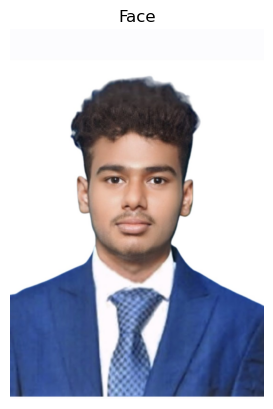

In [2]:
# Load the Face Image
faceImage = cv2.imread("photo.png.jpeg")
plt.imshow(cv2.cvtColor(faceImage, cv2.COLOR_BGR2RGB))
plt.title("Face")
plt.axis("off")

In [28]:
faceImage.shape

(2200, 1700, 3)

In [29]:
#resized_faceImage.shape
faceImage.shape

(2200, 1700, 3)

(np.float64(-0.5), np.float64(626.5), np.float64(272.5), np.float64(-0.5))

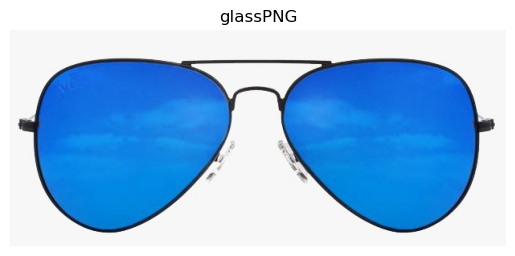

In [3]:
# Load the Sunglass image with Alpha channel
glassPNG = cv2.imread("glass.jpeg", cv2.IMREAD_UNCHANGED)
plt.imshow(cv2.cvtColor(glassPNG, cv2.COLOR_BGRA2RGBA))
plt.title("glassPNG")
plt.axis("off")

In [4]:
# Resize the sunglass to fit the face
# Tuned for the uploaded image
glassPNG = cv2.resize(glassPNG, (170, 63), interpolation=cv2.INTER_AREA)
print(glassPNG.shape)

(63, 170, 3)


In [5]:
# Separate the Color and alpha channels
glassBGR = glassPNG[:,:,0:3]
glassMask1 = glassPNG[:,:,2]
glassBGR.shape

(63, 170, 3)

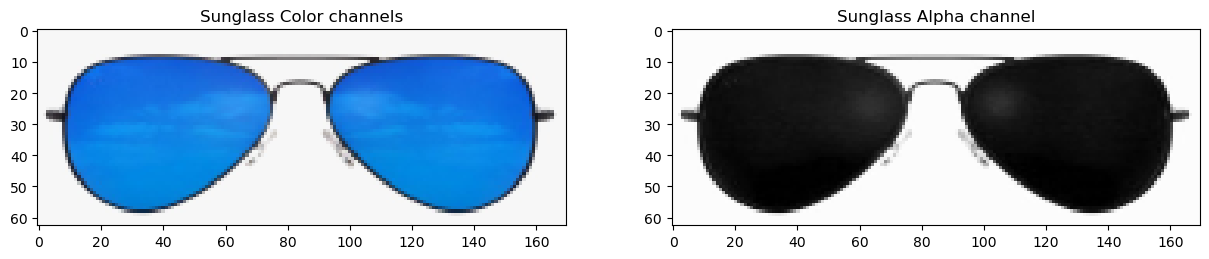

In [6]:
# Display the images for clarity
plt.figure(figsize=[15,15])
plt.subplot(121);plt.imshow(glassBGR[:,:,::-1]);plt.title('Sunglass Color channels');
plt.subplot(122);plt.imshow(glassMask1,cmap='gray');plt.title('Sunglass Alpha channel');

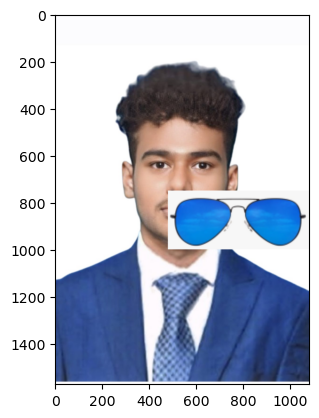

(63, 170, 3)

In [13]:
# Make a copy
faceWithGlassesNaive = faceImage.copy()

# Resize glasses image to match the selected face region
glassBGR_resized = cv2.resize(glassBGR, (600, 250))

# Replace the eye region with the resized glasses image
faceWithGlassesNaive[750:1000, 480:1080] = glassBGR_resized

plt.imshow(faceWithGlassesNaive[..., ::-1])
plt.show()

glassBGR.shape

In [9]:
# Make the dimensions of the mask same as the input image.
# Since Face Image is a 3-channel image, we create a 3 channel image for the mask
glassMask = cv2.merge((glassMask1,glassMask1,glassMask1))

# Make the values [0,1] since we are using arithmetic operations
glassMask = np.uint8(glassMask/255)

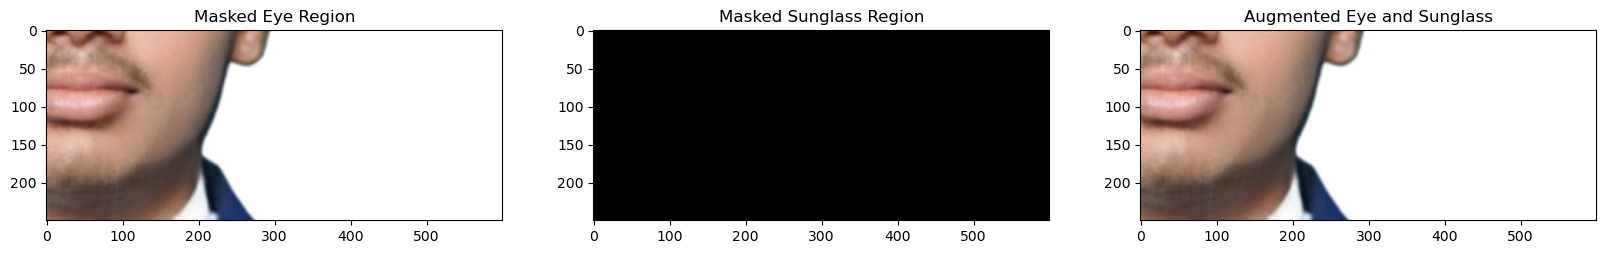

In [14]:
# Make a copy
faceWithGlassesArithmetic = faceImage.copy()

# Get the eye region
eyeROI = faceWithGlassesArithmetic[750:1000, 480:1250]

# Resize sunglasses and mask to match eyeROI
glassBGR_resized = cv2.resize(
    glassBGR,
    (eyeROI.shape[1], eyeROI.shape[0])
)

glassMask_resized = cv2.resize(
    glassMask,
    (eyeROI.shape[1], eyeROI.shape[0]),
    interpolation=cv2.INTER_NEAREST
)

# Convert mask to grayscale if needed
if len(glassMask_resized.shape) == 3:
    glassMask_resized = cv2.cvtColor(
        glassMask_resized,
        cv2.COLOR_BGR2GRAY
    )

# Convert everything to float32
eye_float = eyeROI.astype(np.float32)
glass_float = glassBGR_resized.astype(np.float32)
mask_float = glassMask_resized.astype(np.float32) / 255.0

# Apply mask
maskedEye = eye_float * (1 - mask_float[:, :, np.newaxis])
maskedGlass = glass_float * mask_float[:, :, np.newaxis]

# Combine
eyeRoiFinal = maskedEye + maskedGlass

# Convert back to uint8
eyeRoiFinal = np.clip(eyeRoiFinal, 0, 255).astype(np.uint8)

# Put the result back
faceWithGlassesArithmetic[750:1000, 480:1250] = eyeRoiFinal

# Display
plt.figure(figsize=[20,20])

plt.subplot(131)
plt.imshow(maskedEye.astype(np.uint8)[...,::-1])
plt.title("Masked Eye Region")

plt.subplot(132)
plt.imshow(maskedGlass.astype(np.uint8)[...,::-1])
plt.title("Masked Sunglass Region")

plt.subplot(133)
plt.imshow(eyeRoiFinal[...,::-1])
plt.title("Augmented Eye and Sunglass")

plt.show()

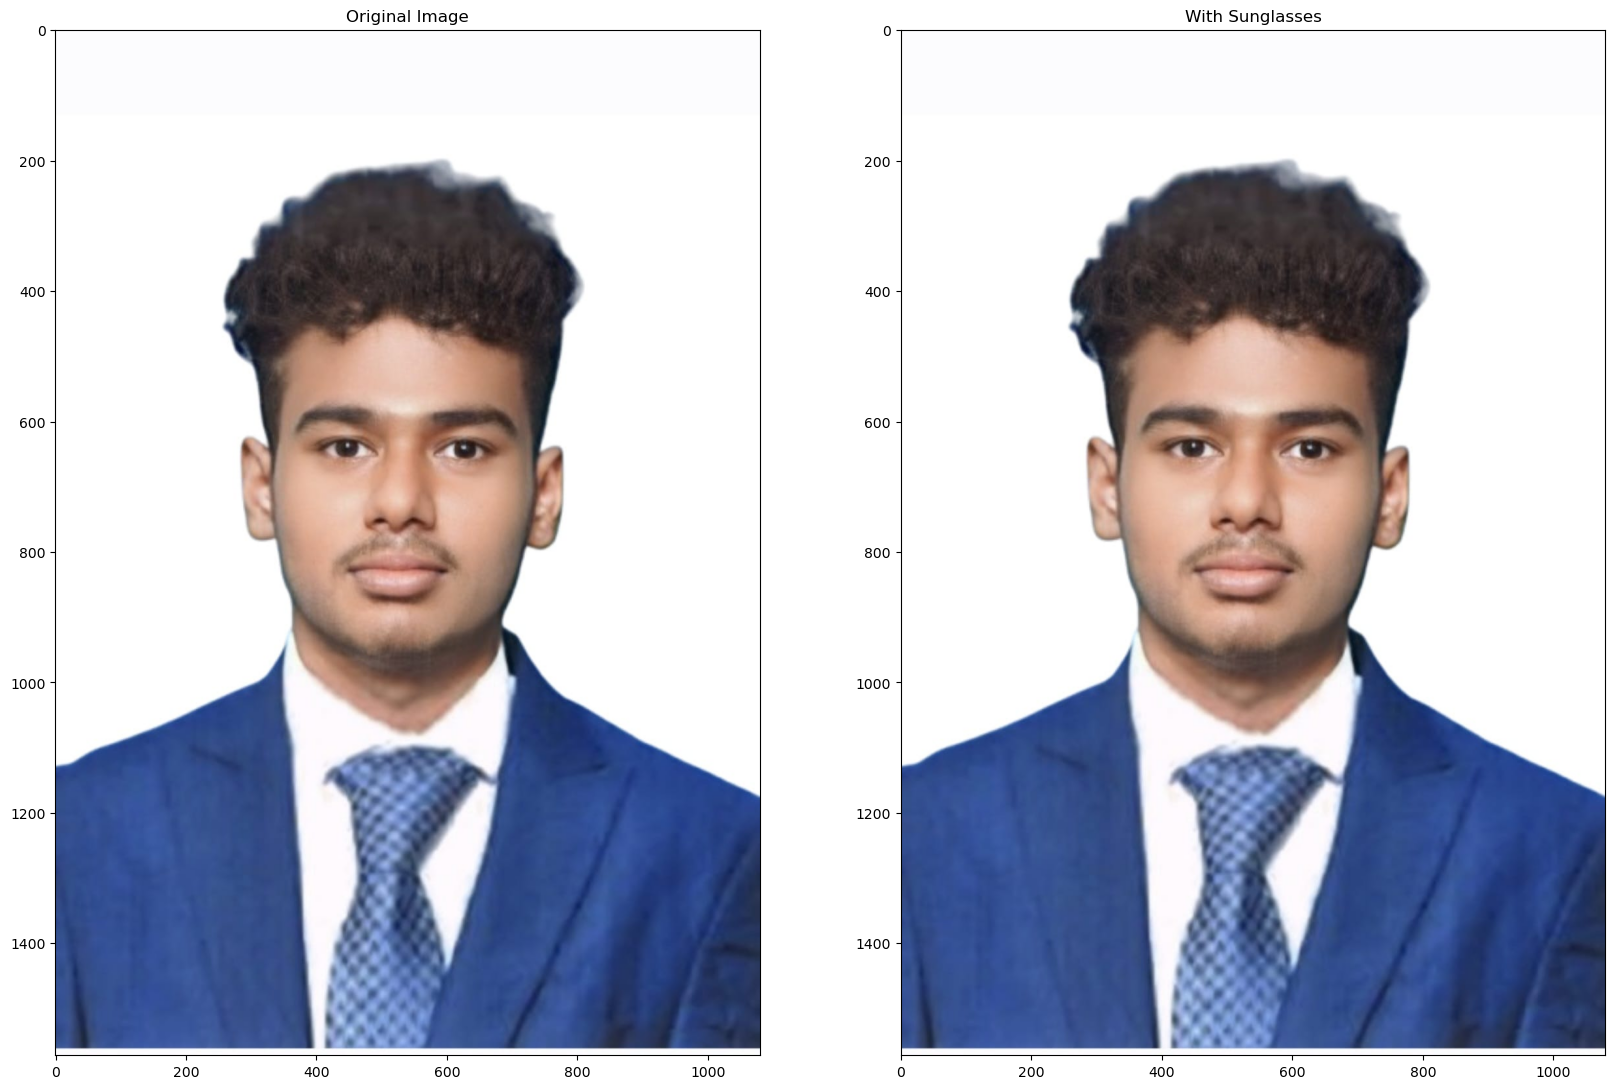

In [15]:
# Replace the eye ROI with the output from the previous section
faceWithGlassesArithmetic[750:1000,480:1250]=eyeRoiFinal

# Display the final result
plt.figure(figsize=[20,20]);
plt.subplot(121);plt.imshow(faceImage[:,:,::-1]); plt.title("Original Image");
plt.subplot(122);plt.imshow(faceWithGlassesArithmetic[:,:,::-1]);plt.title("With Sunglasses");